**Description Of the features of the dataset:**


Y – Latitude coordinate of the observation station.

X – Longitude coordinate of the observation station.

data_payload_id – Unique identifier for the data record.

instance_datetime – Timestamp when the data was recorded.

url – URL reference to the data source.

agency – Organization responsible for the data.

platform_type – Type of platform (e.g., station, balloon, etc.).

platform_id – Numeric ID for the platform.

platform_name – Name of the observation platform or station.

gaw_id – Global Atmosphere Watch ID of the platform.

instrument_name – Name of the instrument used for measurement.

instrument_model – Model of the instrument.

instrument_number – Instrument's identification number.

monthly_date – Date associated with monthly aggregated data.

monthly_columno3 – Monthly average ozone column value.

monthly_stddevo3 – Standard deviation of the monthly ozone values.

monthly_npts – Number of observations used in monthly average.

daily_date – Date of the daily observation.

daily_wlcode – Wavelength code used during observation.

daily_obscode – Observation code (e.g., method or technique).

daily_columno3 – Daily ozone column measurement (Dobson Units).

daily_stddevo3 – Standard deviation of the daily ozone value.

daily_utc_begin – UTC time when observation began.

daily_utc_end – UTC time when observation ended.

daily_utc_mean – Mean UTC time of observation.

daily_nobs – Number of observations for that day.

daily_mmu – Measurement uncertainty for daily ozone.

daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.

latest_observation – Flag indicating if this is the most recent data (0 or 1).

country – Country of the observation station.

scientific_authority – Name of the responsible scientist or authority.

version – Version number of the data record.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import  LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler ,MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [15]:
df=pd.read_csv('New Dataset/spain.csv')
df.head()


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,28.46,-16.25,2306481,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.15,10.52,9.60,4.0,2.181,-0.5,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
1,28.46,-16.25,2306502,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.50,17.88,15.22,12.0,1.421,-1.4,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
2,28.46,-16.25,2306482,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,8.85,14.03,10.80,16.0,1.638,-0.9,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
3,28.46,-16.25,2306480,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.83,17.27,15.41,10.0,1.602,-0.6,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
4,28.46,-16.25,2306483,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.55,17.55,15.04,19.0,1.680,-0.8,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0


In [16]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [17]:
print(f"Date Range: {df.loc[:,'daily_date'][len(df)-1]} to {df.loc[:,'daily_date'][0]}")

Date Range: 1976-01-21 to 2025-03-06


In [ ]:
df=df.drop_duplicates()
df=df.dropna()
df.head()


,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [20]:
round(df.describe(), 3)

,daily_columno3
count,65510.000
mean,310.114
std,34.389
min,-91.500
25%,286.000
50%,305.000
75%,328.600
max,521.800


In [21]:
df.head()
df.dtypes

daily_date         object
daily_columno3    float64
dtype: object

<Figure size 1200x600 with 0 Axes>

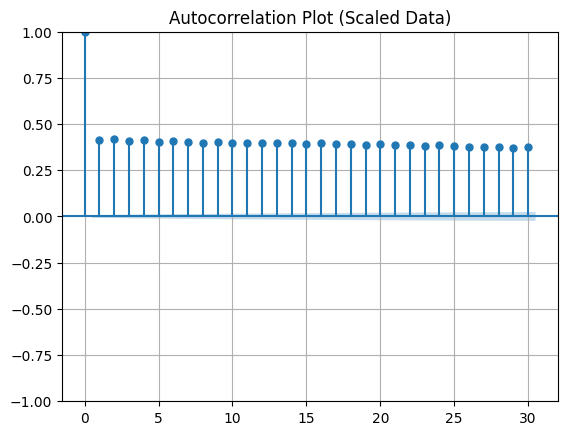

✅ Autocorrelation remains significant for all plotted lags.


In [22]:

acf_vals, confint = acf(df['daily_columno3'], nlags=30, alpha=0.05)

# 4. Calculate threshold from confidence interval
threshold = (confint[:,1] - confint[:,0]) / 2

# 5. Find first inconsistent lag
inconsistent_lag = None
for i, val in enumerate(acf_vals):
    if i == 0:  # Skip lag 0
        continue
    if abs(val) < threshold[i]:
        inconsistent_lag = i
        break

# 6. Plot ACF
plt.figure(figsize=(12,6))
plot_acf(df['daily_columno3'], lags=30, alpha=0.05)
plt.title('Autocorrelation Plot (Scaled Data)')
plt.grid()
plt.show()

# 7. Print result
if inconsistent_lag:
    print(f"👉 Autocorrelation becomes inconsistent after lag {inconsistent_lag}.")
else:
    print("✅ Autocorrelation remains significant for all plotted lags.")



In [23]:
df.head()

,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [24]:
# 2. Sort the dataframe by the full date (oldest to latest)
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (3-day) - To Avoid data leakage, we shift the column by 1 day
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=7).mean()

# Exponential moving average feature (7-day) - To Avoid data leakage, we shift the column by 1 day
df['ema_avg'] = df['daily_columno3'].shift(1).ewm(span=7, adjust=False).mean()


for i in range(1, 101):
    df[f'lag{i}'] = df['daily_columno3'].shift(i)


df.dropna(inplace=True)
print(df.shape)
df.head()

(65410, 104)


,daily_date,daily_columno3,rolling_avg,ema_avg,lag1,lag2,lag3,lag4,lag5,lag6,...,lag91,lag92,lag93,lag94,lag95,lag96,lag97,lag98,lag99,lag100
100,1980-07-01,333.0,342.714286,338.345033,321.0,331.0,349.0,340.0,366.0,356.0,...,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2,257.2,264.0
101,1980-07-02,317.0,342.285714,337.008775,333.0,321.0,331.0,349.0,340.0,366.0,...,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2,257.2
102,1980-07-03,322.0,336.714286,332.006581,317.0,333.0,321.0,331.0,349.0,340.0,...,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2
103,1980-07-04,323.0,330.428571,329.504936,322.0,317.0,333.0,321.0,331.0,349.0,...,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9
104,1980-07-07,327.0,328.000000,327.878702,323.0,322.0,317.0,333.0,321.0,331.0,...,296.2,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7


In [25]:
df.tail()

,daily_date,daily_columno3,rolling_avg,ema_avg,lag1,lag2,lag3,lag4,lag5,lag6,...,lag91,lag92,lag93,lag94,lag95,lag96,lag97,lag98,lag99,lag100
65505,2025-03-31,304.2,318.200000,321.528513,337.5,323.5,296.8,314.8,317.0,310.6,...,363.4,313.1,339.9,316.9,331.7,335.0,311.4,302.4,381.0,432.5
65506,2025-03-31,326.3,314.914286,317.196385,304.2,337.5,323.5,296.8,314.8,317.0,...,303.6,363.4,313.1,339.9,316.9,331.7,335.0,311.4,302.4,381.0
65507,2025-03-31,332.6,317.157143,319.472289,326.3,304.2,337.5,323.5,296.8,314.8,...,373.8,303.6,363.4,313.1,339.9,316.9,331.7,335.0,311.4,302.4
65508,2025-03-31,291.9,319.385714,322.754217,332.6,326.3,304.2,337.5,323.5,296.8,...,349.7,373.8,303.6,363.4,313.1,339.9,316.9,331.7,335.0,311.4
65509,2025-03-31,325.0,316.114286,315.040662,291.9,332.6,326.3,304.2,337.5,323.5,...,345.8,349.7,373.8,303.6,363.4,313.1,339.9,316.9,331.7,335.0


**Using Rolling Average (Lag Value 100 days)**

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 52328, number of used features: 101
[LightGBM] [Info] Start training from score -0.000000
Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.649
MAE : 0.473
R2  : 52.66 %

----- Decision Tree -----
RMSE: 0.926
MAE : 0.671
R2  : 3.69 %

----- Random Forest -----
RMSE: 0.648
MAE : 0.474
R2  : 52.81 %

----- Gradient Boosting -----
RMSE: 0.649
MAE : 0.472
R2  : 52.61 %

----- Support Vector Regressor -----
RMSE: 0.674
MAE : 0.487
R2  : 49.00 %

----- XGBoost -----
RMSE: 0.666
MAE : 0.482
R2  : 50.19 %

----- LightGBM -----
RMSE: 0.648
MAE : 0.471
R2  : 52.80 %



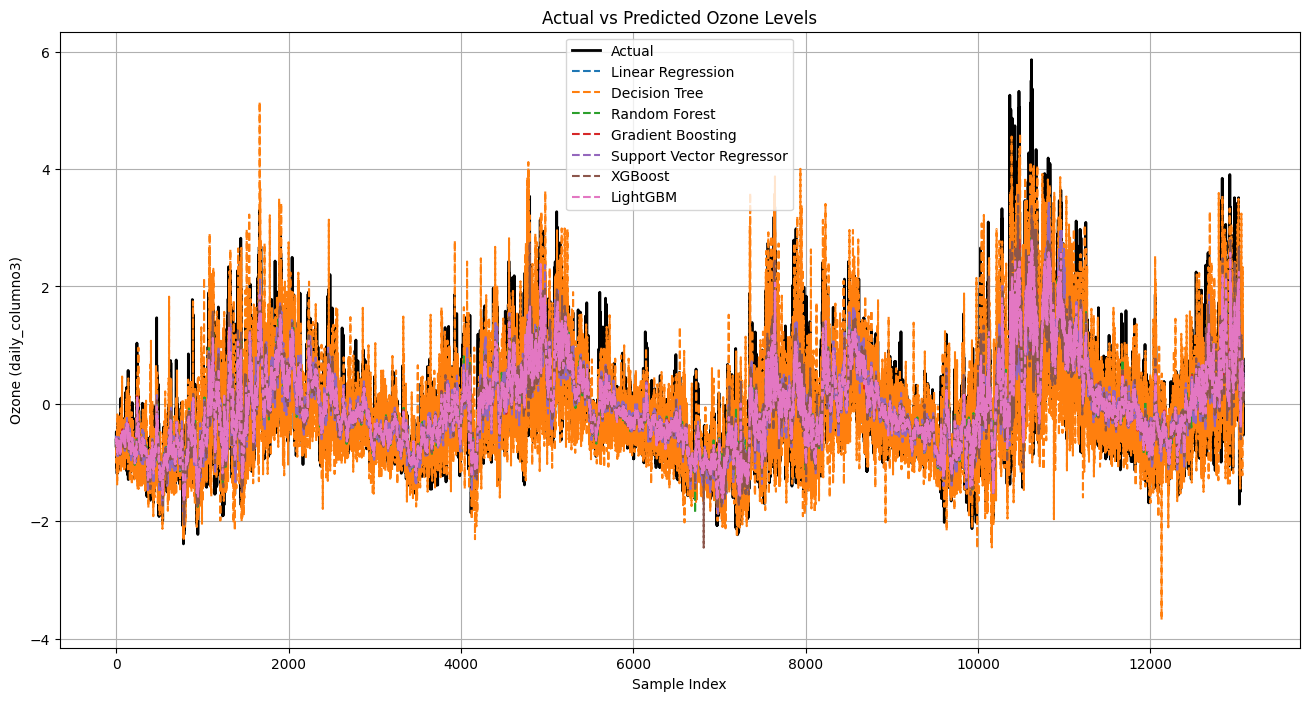

In [27]:
minmax_x = StandardScaler()
minmax_y= StandardScaler()

lag_features = [f'lag{i}' for i in range(1, 101)]
lag_features.append('rolling_avg')
# lag_features.append('ema_avg')
X= df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train = minmax_x.fit_transform(X_train)
y_train = minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
X_test = minmax_x.transform(X_test)
y_test = minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

plt.figure(figsize=(16, 8))

# Actual data
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()

***Hyper Parameter Tuning On Simple Rolling Average (Lag Value 100 days)**

In [ ]:

from sklearn.model_selection import RandomizedSearchCV,ParameterGrid
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42)
}

# Define hyperparameter grids
param_grids = {
    'Linear Regression': {},

    'Decision Tree': {
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Random Forest': {
        'n_estimators': [100, 150],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    },

    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'epsilon': [0.1, 0.01]
    },

    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 1, 5],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 1.5, 2]
    },

    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, -1],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 63],
        'min_child_samples': [10, 20, 30],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [0, 1, 2]
    }
}

# Models that will use RandomizedSearchCV
use_randomized_search = {
    'Random Forest', 'Gradient Boosting', 'Support Vector Regressor', 'XGBoost', 'LightGBM'
}

# Run tuning and evaluation
best_models = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if param_grids[name]:
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=10 if name in use_randomized_search else len(list(ParameterGrid(param_grids[name]))),
            cv=3,
            scoring='r2',
            n_jobs=1,
            verbose=1,
            random_state=42
        )

        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        print(f"{name} Best Parameters: {search.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_models[name] = model

    # Make predictions and calculate metrics
    preds = best_models[name].predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Model': best_models[name],
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Print metrics
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# Plot predictions
plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')
plt.title('Actual vs Predicted Ozone Levels (with Hyperparameter Tuning)')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()


Training Linear Regression...

Training Decision Tree...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Decision Tree Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}

Training Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


**Using Exponantial Average**

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.037
MAE : 0.027
R2  : 52.68 %

----- Decision Tree -----
RMSE: 0.052
MAE : 0.038
R2  : 4.33 %

----- Random Forest -----
RMSE: 0.037
MAE : 0.027
R2  : 52.17 %

----- Gradient Boosting -----
RMSE: 0.037
MAE : 0.027
R2  : 52.64 %

----- Support Vector Regressor -----
RMSE: 0.045
MAE : 0.036
R2  : 30.22 %



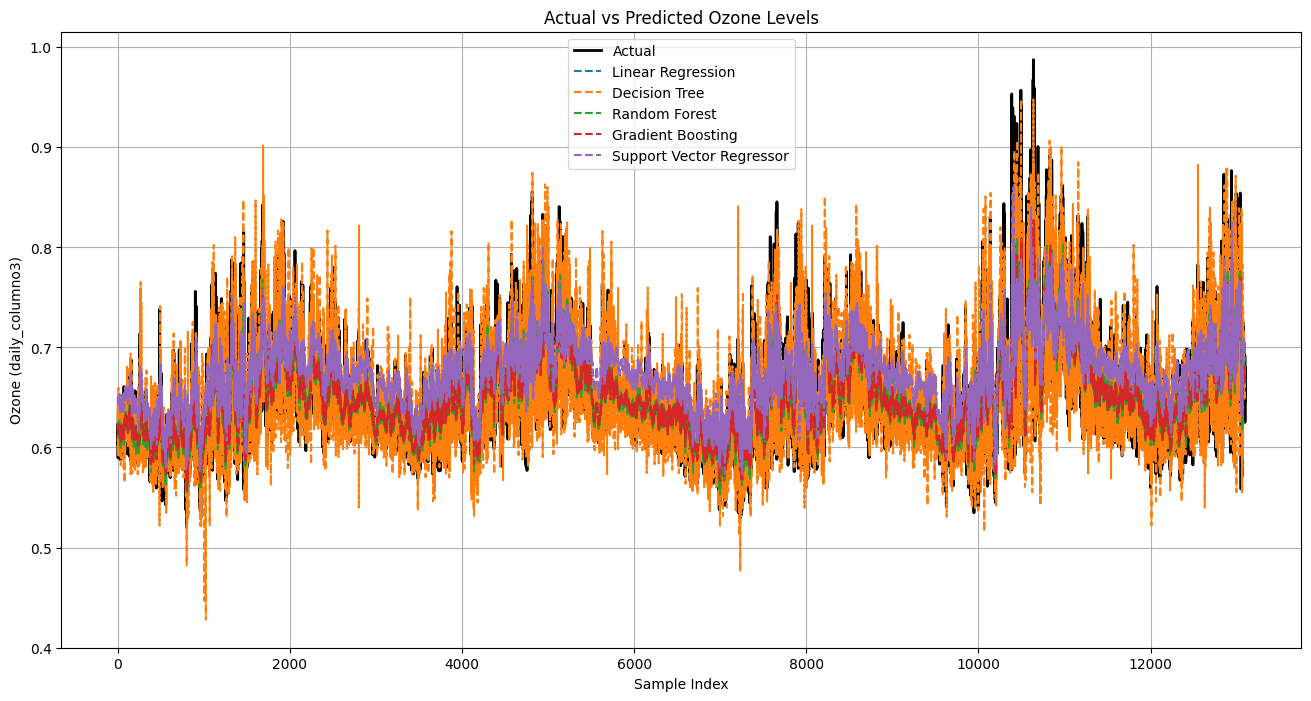

In [ ]:
minmax_x = MinMaxScaler()
minmax_y= MinMaxScaler()
lag_features = [f'lag{i}' for i in range(1, 61)]
# lag_features.append('rolling_avg')
lag_features.append('ema_avg')
X = df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train = minmax_x.fit_transform(X_train)
y_train = minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
X_test = minmax_x.transform(X_test)
y_test = minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

plt.figure(figsize=(16, 8))

# Actual data
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()

**Hyper Parameter Tuning on Exponential Moving Average**


Training Linear Regression...

Training Decision Tree...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Decision Tree Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}

Training Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Forest Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}

Training Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Gradient Boosting Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.1}

Training Support Vector Regressor...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Support Vector Regressor Best Parameters: {'kernel': 'linear', 'epsilon': 0.01, 'C': 10}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.068
MAE : 0.049
R2  : 50.25 %

----- Decision Tree -----
RMSE: 0.068
MAE : 0.050
R2  : 49.41 %

----- Random Forest 

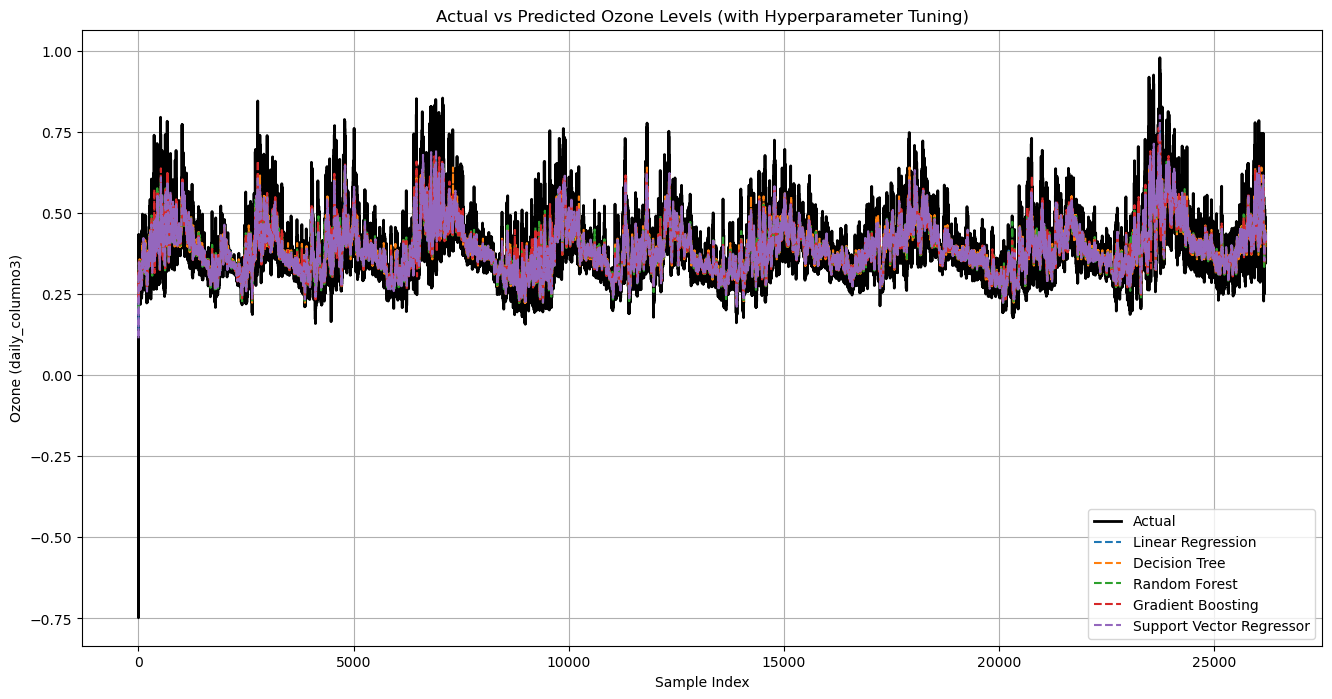

In [ ]:

from sklearn.model_selection import RandomizedSearchCV,ParameterGrid
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42)
}

# Define hyperparameter grids
param_grids = {
    'Linear Regression': {},

    'Decision Tree': {
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Random Forest': {
        'n_estimators': [100, 150],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    },

    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'epsilon': [0.1, 0.01]
    },

    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 1, 5],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 1.5, 2]
    },

    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, -1],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 63],
        'min_child_samples': [10, 20, 30],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [0, 1, 2]
    }
}

# Models that will use RandomizedSearchCV
use_randomized_search = {
    'Random Forest', 'Gradient Boosting', 'Support Vector Regressor', 'XGBoost', 'LightGBM'
}

# Run tuning and evaluation
best_models = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if param_grids[name]:
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=10 if name in use_randomized_search else len(list(ParameterGrid(param_grids[name]))),
            cv=5,
            scoring='r2',
            n_jobs=2,
            verbose=1,
            random_state=42
        )

        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        print(f"{name} Best Parameters: {search.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_models[name] = model

    # Make predictions and calculate metrics
    preds = best_models[name].predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Model': best_models[name],
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Print metrics
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# Plot predictions
plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')
plt.title('Actual vs Predicted Ozone Levels (with Hyperparameter Tuning)')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()

**Trying Different Combinations for trial and Error Purpose**

***Ussing Time series split (on Hold)***


Training Linear Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Training Support Vector Regressor...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004872 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16830
[LightGBM] [Info] Number of data points in the train set: 13036, number of used features: 66
[LightGBM] [Info] Start training from score -0.042815
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16830
[LightGBM] [Info] Number of data points in the train set: 26067, number of used features: 66
[LightGBM] [Info] Start training from score -0.008192
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011662 seconds.
You can set

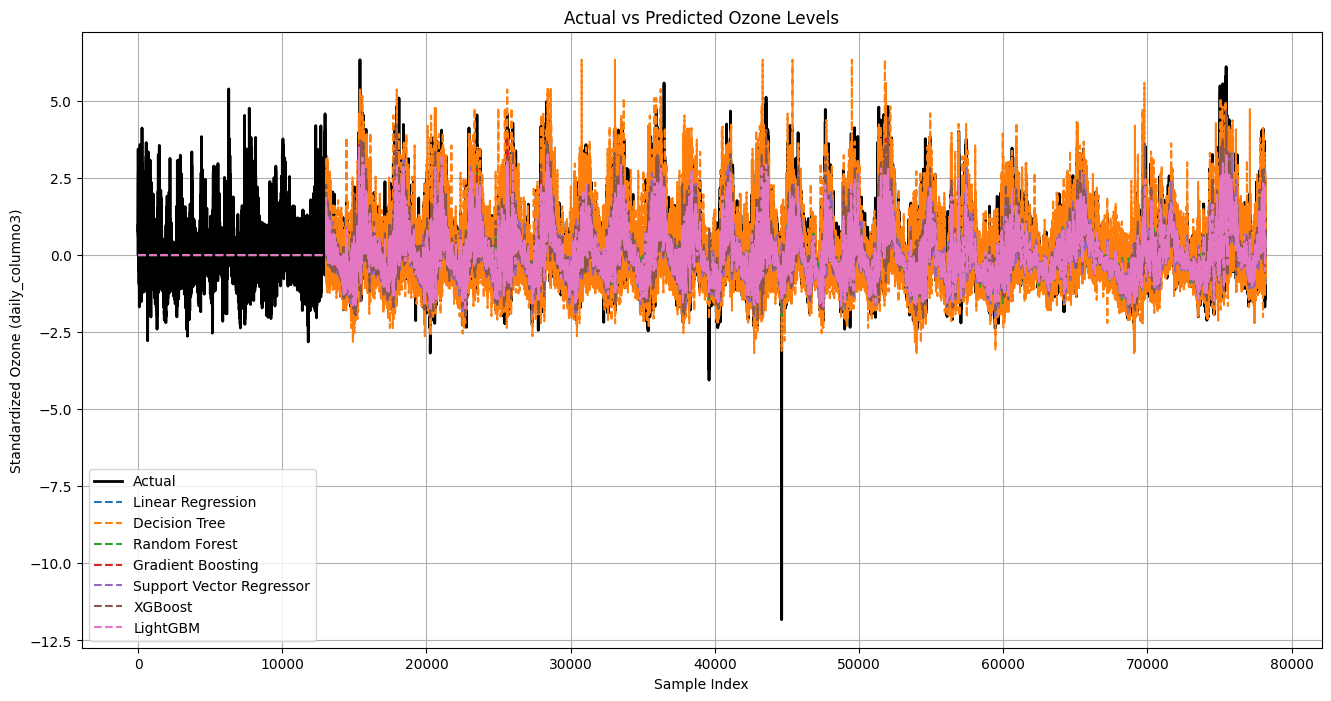

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.svm import SVR
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import matplotlib.pyplot as plt


# # --- Step 1: Feature Engineering ---

# # Sort by date to maintain time order
# df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# # Create lag features
# for i in range(1, 61):  
#     df[f'lag{i}'] = df['daily_columno3'].shift(i)

# # Rolling statistics
# for win in [3, 7, 14]:
#     df[f'rolling_mean_{win}'] = df['daily_columno3'].shift(1).rolling(window=win).mean()
#     df[f'rolling_std_{win}'] = df['daily_columno3'].shift(1).rolling(window=win).std()

# # Drop rows with NaNs from shifting/rolling
# df.dropna(inplace=True)

# # --- Step 2: Scaling ---

# X_cols = [col for col in df.columns if col.startswith('lag') or 'rolling' in col]
# X = df[X_cols]
# y = df['daily_columno3']

# scaler_X = StandardScaler()
# scaler_y = StandardScaler()

# X_scaled = scaler_X.fit_transform(X)
# y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

# # --- Step 3: Time Series Split ---
# tscv = TimeSeriesSplit(n_splits=5)

# # --- Step 4: Define Models ---
# models = {
#     'Linear Regression': LinearRegression(),
#     'Decision Tree': DecisionTreeRegressor(random_state=42),
#     'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
#     'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
#     'Support Vector Regressor': SVR(),
#     'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
#     'LightGBM': LGBMRegressor(n_estimators=100, random_state=42)
# }

# # --- Step 5: Train, Predict, and Evaluate ---
# results = {}

# for name, model in models.items():
#     print(f"\nTraining {name}...")
    
#     fold_scores = []
#     preds_all = np.zeros_like(y_scaled)
#     for train_index, test_index in tscv.split(X_scaled):
#         X_train, X_test = X_scaled[train_index], X_scaled[test_index]
#         y_train, y_test = y_scaled[train_index], y_scaled[test_index]
        
#         model.fit(X_train, y_train)
#         preds = model.predict(X_test)
#         preds_all[test_index] = preds

#     mse = mean_squared_error(y_scaled, preds_all)
#     rmse = np.sqrt(mse)
#     mae = mean_absolute_error(y_scaled, preds_all)
#     r2 = r2_score(y_scaled, preds_all)

#     results[name] = {
#         'Model': model,
#         'Predictions': preds_all,
#         'MSE': mse,
#         'RMSE': rmse,
#         'MAE': mae,
#         'R2': r2
#     }

# # --- Step 6: Print Evaluation Metrics ---
# print("\nModel Evaluation Metrics:\n")
# for name, res in results.items():
#     print(f"----- {name} -----")
#     print(f"RMSE: {res['RMSE']:.3f}")
#     print(f"MAE : {res['MAE']:.3f}")
#     print(f"R2  : {(res['R2']*100):.2f} %\n")

# # --- Step 7: Plot Predictions ---
# plt.figure(figsize=(16, 8))
# plt.plot(np.arange(len(y_scaled)), y_scaled, label='Actual', color='black', linewidth=2)
# for name, res in results.items():
#     plt.plot(np.arange(len(y_scaled)), res['Predictions'], label=name, linestyle='--')
# plt.title('Actual vs Predicted Ozone Levels')
# plt.xlabel('Sample Index')
# plt.ylabel('Standardized Ozone (daily_columno3)')
# plt.legend()
# plt.grid(True)
# plt.show()
